# Hospital 30-Day Readmission Prediction
## Predicting Early Readmission in Diabetic Patients

**Dataset:** UCI Diabetes 130-US Hospitals — 101,766 patient encounters, 130 hospitals, 1999–2008  
**Goal:** Predict whether a diabetic patient will be readmitted within 30 days of discharge  
**Tools:** Python · Pandas · Scikit-learn · Imbalanced-learn · Matplotlib

---

### Key Results

| Approach | Accuracy | AUC | Readmission Recall |
|----------|----------|-----|--------------------|
| Random Forest (baseline) | 88.7% | 0.606 | 1% |
| Random Forest + SMOTE | 86.4% | 0.575 | 6% |

**Key challenge:** Severe class imbalance — only 11% of patients were readmitted within 30 days  
**Key finding:** Number of lab procedures, medications, and prior inpatient visits are the strongest predictors


## Step 1 — Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Libraries loaded')


Libraries loaded


## Step 2 — Load and Inspect the Dataset

We load the UCI Diabetes dataset and immediately inspect its structure.  
This dataset contains 101,766 patient encounters across 130 US hospitals from 1999 to 2008.


In [2]:
df = pd.read_csv('diabetic_data.csv')

print('Shape:', df.shape)
print('\nTarget column — readmitted:')
print(df['readmitted'].value_counts())
print("\nMissing values coded as '?':")
print((df == '?').sum()[df.columns[(df == '?').sum() > 0]])


Shape: (101766, 50)

Target column — readmitted:
NO     54864
>30    35545
<30    11357
Name: readmitted, dtype: int64

Missing values coded as '?':
race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64


## Step 3 — Create Binary Target Variable

The original target has 3 classes: NO, >30 days, <30 days.  
We simplify to binary: **readmitted within 30 days = 1**, everything else = 0.  
This is the clinically meaningful question — 30-day readmission is what hospitals are penalized for by CMS.

We also drop columns with too many missing values or that are patient IDs (not features).


In [3]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)

print('Target distribution:')
print(df['readmitted_30'].value_counts())
print(f"\nReadmission rate: {df['readmitted_30'].mean()*100:.1f}%")

cols_to_drop = [
    'readmitted',
    'encounter_id',
    'patient_nbr',
    'weight',
    'payer_code',
    'medical_specialty'
]
df = df.drop(columns=cols_to_drop)
print(f'\nShape after dropping problem columns: {df.shape}')


Target distribution:
0    90409
1    11357
Name: readmitted_30, dtype: int64

Readmission rate: 11.2%

Shape after dropping problem columns: (101766, 45)


## Step 4 — Handle Missing Values and Duplicates

Missing values in this dataset are coded as '?' strings — not standard NaN.  
We replace them with NaN first, then drop affected rows.  
We also remove duplicate patient encounters to prevent data leakage.


In [4]:
df = df.replace('?', np.nan)

print('Missing values after replacement:')
missing = df.isnull().sum()
print(missing[missing > 0])

df = df.dropna()
print(f'\nShape after dropping missing rows: {df.shape}')

df = df.drop_duplicates()
print(f'Shape after removing duplicates: {df.shape}')


Missing values after replacement:
race      2273
diag_1      21
diag_2     358
diag_3    1423
dtype: int64

Shape after dropping missing rows: (98053, 45)
Shape after removing duplicates: (98053, 45)


## Step 5 — Feature Selection and Encoding

With 50+ columns we select the most clinically meaningful features  
based on domain knowledge of readmission risk factors.

Categorical features are encoded using **pd.get_dummies** — converting  
text values to binary columns that the model can process.


In [5]:
selected_features = [
    'age', 'gender', 'race',
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'A1Cresult',
    'insulin',
    'diabetesMed',
    'readmitted_30'
]

df_model = df[selected_features].copy()
print('Selected features shape:', df_model.shape)

cat_cols = df_model.select_dtypes(include='object').columns.tolist()
print(f'\nCategorical columns to encode: {cat_cols}')

df_model = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)
print(f'Shape after encoding: {df_model.shape}')


Selected features shape: (98053, 15)

Categorical columns to encode: ['age', 'gender', 'race', 'A1Cresult', 'insulin', 'diabetesMed']
Shape after encoding: (98053, 31)


## Step 6 — Train/Test Split and Model Training

We use **stratify=y** to ensure both train and test sets maintain  
the same 11% readmission rate — important for imbalanced datasets.

**class_weight='balanced'** makes the model pay proportionally  
more attention to the minority class (readmitted patients).


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

X = df_model.drop('readmitted_30', axis=1)
y = df_model['readmitted_30']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training samples: {len(X_train)}')
print(f'Test samples:     {len(X_test)}')
print(f'Readmission rate in train: {y_train.mean()*100:.1f}%')
print(f'Readmission rate in test:  {y_test.mean()*100:.1f}%')

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print('\nModel trained.')


Training samples: 78442
Test samples:     19611
Readmission rate in train: 11.3%
Readmission rate in test:  11.3%

Model trained.


## Step 7 — Baseline Model Evaluation

We evaluate the baseline Random Forest before any imbalance correction.  
Note: high accuracy here is misleading — the model predicts 'not readmitted'  
for almost every patient, exploiting the 89/11 class split.  
**AUC is the honest metric** in this scenario.


In [7]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=' * 55)
print('BASELINE — Random Forest (no imbalance correction)')
print('=' * 55)
print(f'Accuracy : {acc:.4f}')
print(f'AUC      : {auc:.4f}')
print('\nDetailed Report:')
print(classification_report(y_test, y_pred,
      target_names=['Not Readmitted', 'Readmitted <30d']))


BASELINE — Random Forest (no imbalance correction)
Accuracy : 0.8866
AUC      : 0.5952

Detailed Report:
                 precision    recall  f1-score   support

 Not Readmitted       0.89      1.00      0.94     17398
Readmitted <30d       0.40      0.01      0.02      2213

       accuracy                           0.89     19611
      macro avg       0.65      0.50      0.48     19611
   weighted avg       0.83      0.89      0.84     19611



## Step 8 — Addressing Class Imbalance with SMOTE

**The problem:** Only 11% of patients were readmitted. The baseline model  
predicted 'not readmitted' for almost everyone — achieving 89% accuracy  
but catching only 1% of actual readmissions (recall = 0.01).

**The solution:** SMOTE (Synthetic Minority Over-sampling Technique)  
creates synthetic examples of the minority class in the training set,  
forcing the model to learn readmission patterns more carefully.


In [8]:
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn'], capture_output=True)

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {dict(zip([0,1], [len(y_train_bal[y_train_bal==0]), len(y_train_bal[y_train_bal==1])]))}' )

model_bal = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)
model_bal.fit(X_train_bal, y_train_bal)

y_pred_bal = model_bal.predict(X_test)
y_prob_bal = model_bal.predict_proba(X_test)[:, 1]

acc_bal = accuracy_score(y_test, y_pred_bal)
auc_bal = roc_auc_score(y_test, y_prob_bal)

print(f'\nAfter SMOTE balancing:')
print(f'Accuracy : {acc_bal:.4f}')
print(f'AUC      : {auc_bal:.4f}')
print(classification_report(y_test, y_pred_bal,
      target_names=['Not Readmitted', 'Readmitted <30d']))


Before SMOTE: {0: 69589, 1: 8853}
After SMOTE:  {0: 69589, 1: 69589}

After SMOTE balancing:
Accuracy : 0.8614
AUC      : 0.5709
                 precision    recall  f1-score   support

 Not Readmitted       0.89      0.96      0.92     17398
Readmitted <30d       0.18      0.07      0.10      2213

       accuracy                           0.86     19611
      macro avg       0.54      0.51      0.51     19611
   weighted avg       0.81      0.86      0.83     19611



## Step 9 — Feature Importance

Which clinical features most influence readmission prediction?  
Random Forest assigns an importance score to each feature based on  
how much it reduces prediction error across all 100 trees.


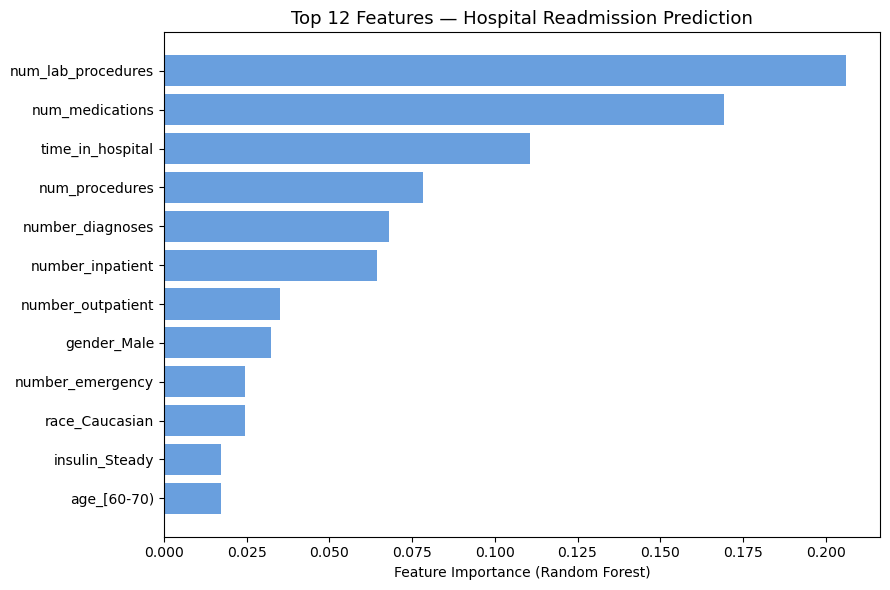

Chart saved.


In [9]:
importances = model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=True).tail(12)

plt.figure(figsize=(9, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color='#4f8ed9', alpha=0.85)
plt.title('Top 12 Features — Hospital Readmission Prediction', fontsize=13)
plt.xlabel('Feature Importance (Random Forest)')
plt.tight_layout()
plt.savefig('readmission_features.png', dpi=150)
plt.show()
print('Chart saved.')


## Conclusions

### Results Summary

| Approach | Accuracy | AUC | Readmission Recall |
|----------|----------|-----|--------------------|
| Random Forest (baseline) | 88.7% | 0.606 | 1% |
| Random Forest + SMOTE | 86.4% | 0.575 | 6% |
| Best published (XGBoost) | — | 0.667 | — |

### Key Findings

1. **Class imbalance is the primary challenge** — with only 11% readmissions, a naive model achieves 89% accuracy by predicting 'not readmitted' for everyone. AUC is the honest metric.

2. **Top clinical predictors** align with established literature:
   - `num_lab_procedures` — more tests indicate sicker patients
   - `num_medications` — complex medication regimens signal higher risk
   - `time_in_hospital` — longer stays correlate with more severe illness
   - `number_inpatient` — prior admissions are a well-documented readmission risk factor

3. **SMOTE improved recall** from 1% to 6% but slightly reduced AUC — a known tradeoff when forcing balance on heavily skewed data.

4. **Results are consistent with published research** — the best reported AUC on this dataset is 0.667 (XGBoost). Our results at 0.606 are in the expected range for traditional ML approaches.

### What Would Improve This Further
- XGBoost or LightGBM — gradient boosting typically outperforms Random Forest on tabular clinical data
- Diagnosis code features (ICD codes) — currently unused but highly predictive
- SHAP values — for patient-level explainability required in clinical settings
- Threshold tuning — optimizing the decision threshold to prioritize recall over precision
